In [19]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F


In [35]:
# Let's load the miRNA data
miRNA = pd.read_csv('data/BRCA.miRNA_RPM_tumor.csv', sep=';')
miRNA = miRNA.set_index('miRNA_ID')

# Let's remove the rows with all zeros
zero_rows = (miRNA == 0).all(axis=1)
miRNA = miRNA[~zero_rows]

# We need to transpose the data to have the patients as rows
miRNA = miRNA.T

# Let's transform the data into a tensor
miRNA_tensor = torch.tensor(miRNA.values, dtype=torch.float32)

miRNA_min = miRNA_tensor.min()
miRNA_max = miRNA_tensor.max()

miRNA_tensor = (miRNA_tensor - miRNA_min) / (miRNA_max - miRNA_min)

# Finally we need to build the data loader
data_loader = torch.utils.data.DataLoader(miRNA_tensor, batch_size=128, shuffle=True)


In [ ]:
miRNA_tensor[:,1]

tensor([11621.9238, 10303.0996, 10949.8682,  ..., 16754.2051, 10638.6387,
        13982.6553])

In [30]:
class VAE(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # latent mean and variance

        self.mean_layer = nn.Linear(latent_dim, latent_dim)
        self.logvar_layer = nn.Linear(latent_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self,x):
        x = self.encoder(x)
        mean, log_var = self.mean_layer(x), self.logvar_layer(x)
        return mean, log_var

    def decode(self, x):
        return self.decoder(x)

    def reparameterization(self, mean, var):
        eps = torch.randn_like(var)
        z = mean + eps*var
        return z
    
    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterization(mean, log_var)
        return self.decode(z), mean, log_var
        

In [36]:
model = VAE(input_dim=miRNA_tensor.shape[1], hidden_dim=128, latent_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss + KLD

Epoch 1 loss: 650.619615342882
Epoch 2 loss: 650.5789761013455
Epoch 3 loss: 650.5356953938802
Epoch 4 loss: 650.522691514757
Epoch 5 loss: 650.4749688042534
Epoch 6 loss: 650.4342549641927
Epoch 7 loss: 650.4046936035156
Epoch 8 loss: 650.3700595431858
Epoch 9 loss: 650.3504604763455
Epoch 10 loss: 650.3186238606771
Epoch 11 loss: 650.2280544704861
Epoch 12 loss: 650.1724175347222
Epoch 13 loss: 650.1340162489149
Epoch 14 loss: 650.0927022298177
Epoch 15 loss: 650.0576680501302
Epoch 16 loss: 650.0140889485677
Epoch 17 loss: 649.9877149793837
Epoch 18 loss: 649.9792751736111
Epoch 19 loss: 649.939707438151
Epoch 20 loss: 649.8870340983073
Epoch 21 loss: 649.8617418077257
Epoch 22 loss: 649.8582865397135
Epoch 23 loss: 649.8194546169705
Epoch 24 loss: 649.7849324544271
Epoch 25 loss: 649.8173251681858
Epoch 26 loss: 649.8121371799045
Epoch 27 loss: 649.6907687717014
Epoch 28 loss: 649.5968424479166
Epoch 29 loss: 649.5652601453993
Epoch 30 loss: 649.5350782606337
Epoch 31 loss: 649.483

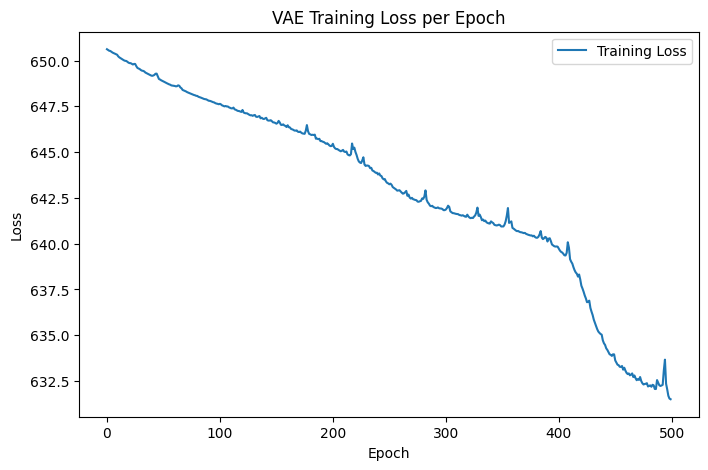

In [42]:
def train_model(model, optimizer, loss_function, num_epochs=10):
    model.train()
    epoch_losses = []
    for epoch in range(num_epochs):
        overall_loss = 0
        for batch_idx, x in enumerate(data_loader):
            x_hat, mean, log_var = model(x)
            optimizer.zero_grad()
            loss = loss_function(x, x_hat, mean, log_var)
            loss.backward()
            optimizer.step()
            overall_loss += loss.item()
        
        avg_loss = overall_loss / len(data_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1} loss: {avg_loss}")
    return epoch_losses

import matplotlib.pyplot as plt

# Get the loss per epoch by training the model
losses = train_model(model, optimizer, loss_function, num_epochs=500)

# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss per Epoch')
plt.legend()
plt.show()

